In [1]:
import calendar
from pathlib import Path
from typing import List, Optional, Union

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Customer Level

In [2]:
train_targets = pd.read_csv("data/train_targets.csv", low_memory=False)

In [3]:
train_targets.head()

,cust_id,revenue_2018_2019
0,klantwj2374mzmab,209.85
1,a63atwr2ig2jfprr,82.93
2,zr7ihbfbi6gcy2tz,89.95
3,dt7cthjqnjmkbiu6,0.00
4,3mytihagykiecpfl,220.00


so some customers have churned, i.e. they had at least one purchase in 2016-17 but did not return in 2018

In [4]:
train_targets["revenue_2018_2019"].max()

np.float64(1197.94)

In [5]:
train_targets["revenue_2018_2019"].min()

np.float64(0.0)

In [6]:
train_targets["revenue_2018_2019"].mode()

0    0.0
Name: revenue_2018_2019, dtype: float64

In [7]:
train_targets.describe()

,revenue_2018_2019
count,93288.000000
mean,70.301258
std,143.954281
min,0.000000
25%,0.000000
50%,0.000000
75%,80.960000
max,1197.940000


In [8]:
churned_percent = sum(train_targets["revenue_2018_2019"] == 0) / len(train_targets)

In [9]:
print(f"{churned_percent * 100:.2f}% of the customers have churned")

63.40% of the customers have churned


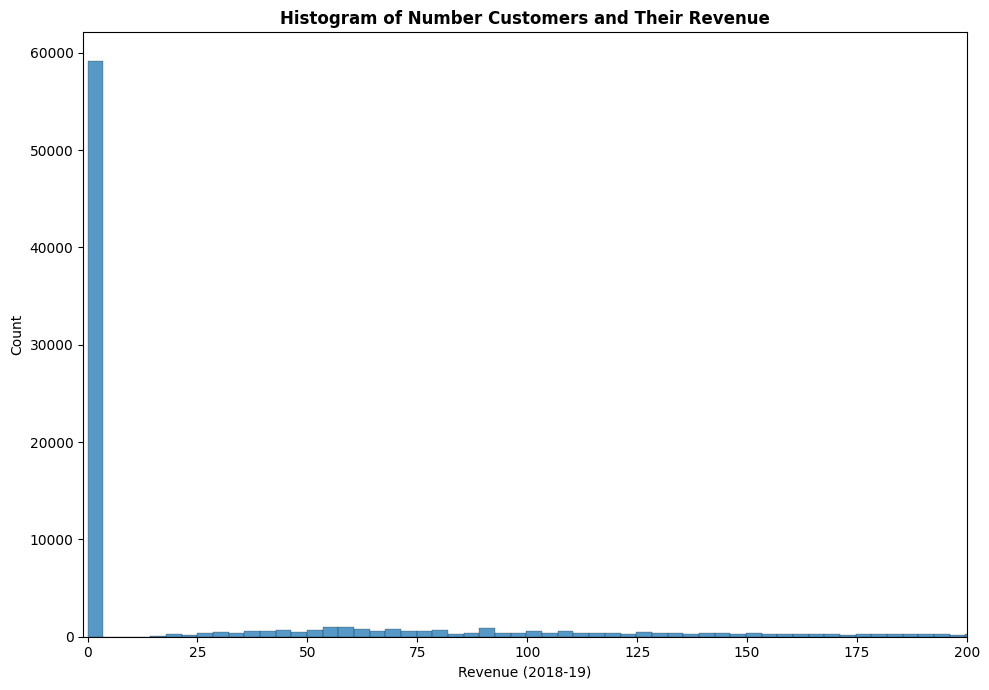

In [10]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.histplot(data=train_targets, ax=ax, x="revenue_2018_2019")
ax.set_title("Histogram of Number Customers and Their Revenue", fontweight="bold")
ax.set(xlabel="Revenue (2018-19)")
ax.set_xlim(-1, 200)

fig.tight_layout()

In [11]:
not_churned = train_targets[train_targets["revenue_2018_2019"] != 0]

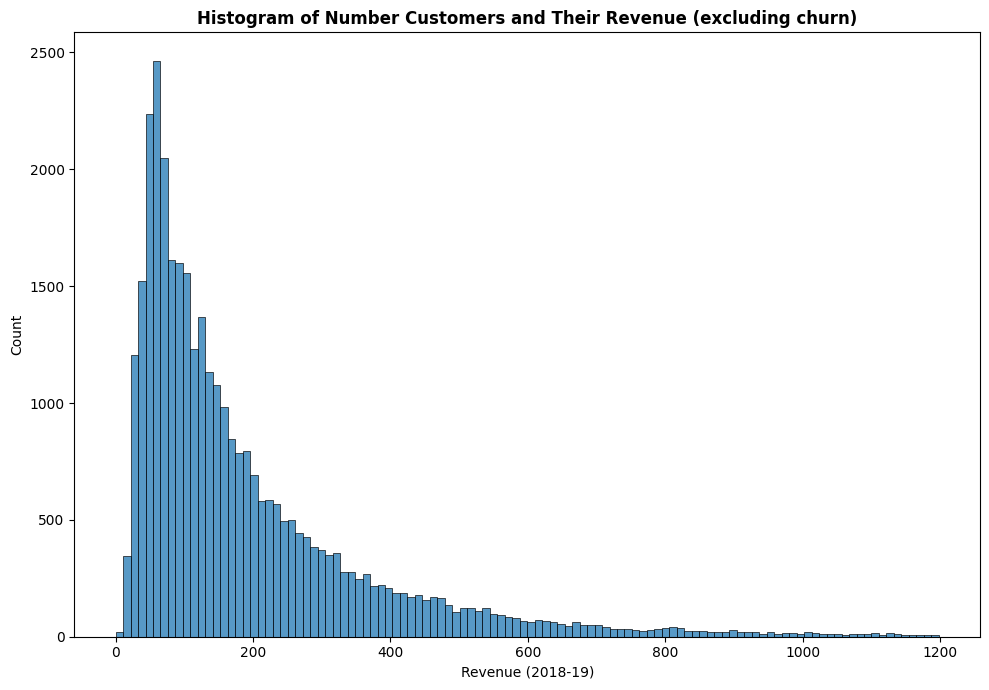

In [12]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.histplot(data=not_churned, ax=ax, x="revenue_2018_2019")
ax.set_title(
    "Histogram of Number Customers and Their Revenue (excluding churn)",
    fontweight="bold",
)
ax.set(xlabel="Revenue (2018-19)")

fig.tight_layout()

# Transaction Level

In [13]:
df_train = pd.read_csv(
    "data/train_clean.csv",
    low_memory=False,
    parse_dates=["order_date", "pack_date"],
)

In [14]:
df_train.head()

,cust_id,order_date,pack_date,sale_id,sale_discount_applied,sale_revenue,returned_to_shop_id,prod_id,prod_size,prod_web_only,...,prod_type_4,prod_type_5,prod_heel,prod_material,prod_insole,prod_print,prod_comfort_sole,prod_comfort_wear,prod_clasp,prod_outlet
0,klantwj2374mzmab,2016-01-01,2016-01-04,wa46phiwo6neterg,-35.70,83.30,NaN,543rj4mzzjnzkbil,30.0,0,...,NaN,boots (velcro),NaN,leather,1.0,NaN,NaN,NaN,velcro,0
1,klantwj2374mzmab,2016-01-01,2016-01-04,wa46phiwo6neterg,-39.98,0.00,ztodvuuaje,7ewnqhtrquent4cy,44.0,0,...,NaN,dress boots,NaN,leather,0.0,NaN,NaN,NaN,zipper,0
2,a63atwr2ig2jfprr,2016-01-01,2016-01-04,p4y4726y24dcxawf,-24.00,0.00,5tiaacoboa,cwtye5jwqr43a56i,38.5,0,...,high-top sneakers,lace-up shoes,NaN,suede,NaN,NaN,NaN,NaN,NaN,0
3,zr7ihbfbi6gcy2tz,2016-01-01,2016-01-05,3etkl2xv6pxku4kt,-26.23,43.72,NaN,mqw2seipp2wtylnw,35.0,0,...,NaN,velcro shoes,NaN,synthetic leather,0.0,NaN,NaN,breathable,velcro,0
4,dt7cthjqnjmkbiu6,2016-01-01,2016-01-05,lneitdgyfvrie3jo,-29.98,0.00,geja5b25na,5ut47kvr6zlx6y62,25.0,0,...,NaN,boots (velcro),NaN,NaN,NaN,NaN,NaN,NaN,velcro,0


In [15]:
df_train[["sale_revenue", "sale_discount_applied"]].describe()

,sale_revenue,sale_discount_applied
count,275092.000000,275092.000000
mean,53.095607,-20.644166
std,38.175805,22.484430
min,-101.250000,-198.750000
25%,26.990000,-31.500000
50%,53.000000,-12.000000
75%,75.950000,-4.590000
max,275.000000,1.000000


In [16]:
df_train["returned_to_shop_id"].isna().sum()  # these were not returned

np.int64(223720)

In [17]:
df_train["is_returned"] = np.where(df_train["returned_to_shop_id"].notna(), 1, 0)

I created the feature `is_returned` here because I wanted to check somethings

In [18]:
df_train["is_returned"].value_counts()

is_returned
0    223720
1     51372
Name: count, dtype: int64

## `sale_revenue`

In [19]:
df_train[df_train["sale_revenue"] < 0].loc[:, ["sale_revenue", "is_returned"]]

,sale_revenue,is_returned
128,-5.00,1
180,-1.50,1
181,-5.88,1
287,-1.40,1
393,-4.22,1
...,...,...
273736,-5.00,1
273739,-15.00,1
274309,-1.67,1
274310,-1.67,1


In [20]:
df_train.loc[:, ["sale_revenue", "is_returned"]].corr()

,sale_revenue,is_returned
sale_revenue,1.000000,-0.669023
is_returned,-0.669023,1.000000


In [21]:
df_train[(df_train["sale_revenue"] > 0) & (df_train["is_returned"] == 1)].loc[
    :, ["sale_revenue", "is_returned"]
]

,sale_revenue,is_returned
1205,21.00,1
4595,11.50,1
5695,6.60,1
20278,0.90,1
20381,5.39,1
...,...,...
229415,0.41,1
229489,0.23,1
229772,2.50,1
247873,26.98,1


## `sale_discount_applied`

In [22]:
(df_train["sale_discount_applied"] > 0).sum()

np.int64(2)

there are rows in which the applied discount is 1

In [23]:
mask = df_train["sale_discount_applied"] > 0

In [24]:
df_train[mask]

,cust_id,order_date,pack_date,sale_id,sale_discount_applied,sale_revenue,returned_to_shop_id,prod_id,prod_size,prod_web_only,...,prod_type_5,prod_heel,prod_material,prod_insole,prod_print,prod_comfort_sole,prod_comfort_wear,prod_clasp,prod_outlet,is_returned
154029,b4gqo6xi23xmp2lk,2017-03-22,2017-03-23,cukff3g2lhfxu4kb,1.0,0.0,m4u2pedciy,ueyjufmqz6cfh3mj,32.0,0,...,low-top sneakers,<2.5 cm,leather,1.0,hearts,NaN,NaN,laces,0,1
154390,zwmqge62dyjvigcc,2017-03-23,2017-03-24,gx4igp6kj2jlnydw,1.0,0.0,m4u2pedciy,ueyjufmqz6cfh3mj,32.0,0,...,low-top sneakers,<2.5 cm,leather,1.0,hearts,NaN,NaN,laces,0,1


In [25]:
abs(df_train["sale_discount_applied"]) / (
    abs(df_train["sale_discount_applied"]) + df_train["sale_revenue"]
)

0         0.300000
1         1.000000
2         1.000000
3         0.374982
4         1.000000
            ...   
275087    0.200000
275088    0.099929
275089    0.149955
275090    0.299937
275091    0.200000
Length: 275092, dtype: float64

## exploring `order_date` and `pack_date`

In [26]:
sales_revenue_by_month = df_train.groupby(df_train["order_date"].dt.month)[
    "sale_revenue"
].sum()

In [27]:
sales_revenue_by_month

order_date
1     2205158.62
2      571911.42
3      816980.69
4     1164877.48
5     1216912.38
6     1220945.87
7     1949971.56
8      994803.98
9     1005357.18
10    1247474.08
11     906862.02
12    1304921.39
Name: sale_revenue, dtype: float64

In [28]:
sales_revenue_by_month.index = [
    calendar.month_name[m] for m in sales_revenue_by_month.index
]

In [29]:
sales_revenue_by_month

January      2205158.62
February      571911.42
March         816980.69
April        1164877.48
May          1216912.38
June         1220945.87
July         1949971.56
August        994803.98
September    1005357.18
October      1247474.08
November      906862.02
December     1304921.39
Name: sale_revenue, dtype: float64

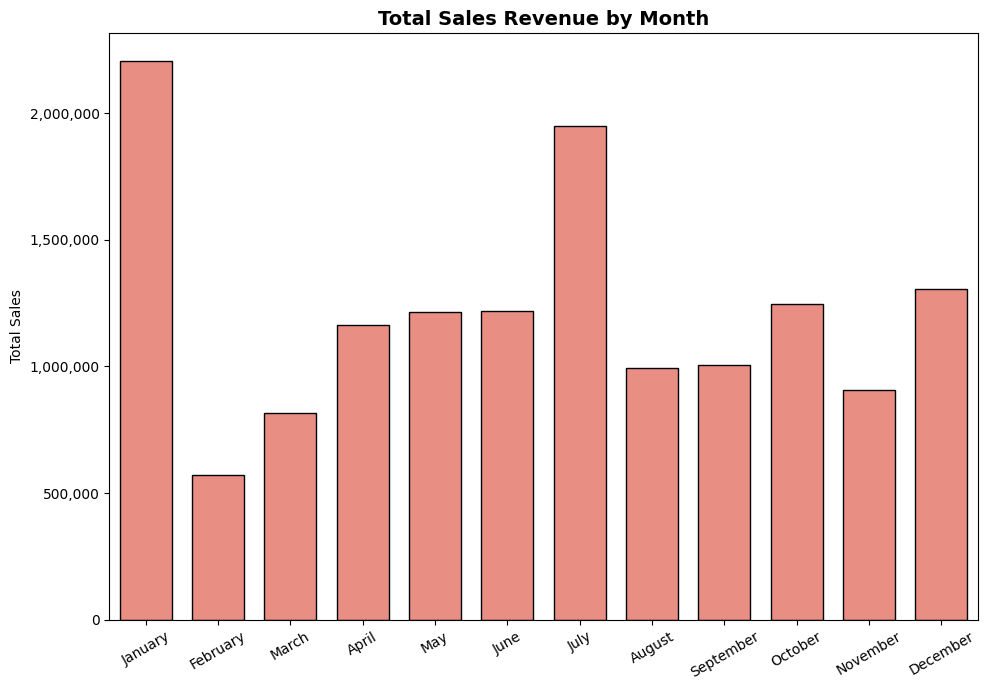

In [30]:
fig, ax = plt.subplots(figsize=(10, 7))


sns.barplot(data=sales_revenue_by_month, gap=0.1, color="salmon", edgecolor="black")  # type: ignore
ax.set_xticks(range(len(sales_revenue_by_month.index)))
ax.set_xticklabels(sales_revenue_by_month.index, rotation=30)

ax.set_title("Total Sales Revenue by Month", fontsize=14, fontweight="bold")
ax.set(ylabel="Total Sales")

fmt = "{x:,.0f}"
tick = mtick.StrMethodFormatter(fmt)
ax.yaxis.set_major_formatter(tick)

fig.tight_layout()

In [31]:
(df_train["pack_date"] - df_train["order_date"]).value_counts()

0 days      93061
1 days      64597
2 days      45605
3 days      33414
4 days      19075
5 days       9940
6 days       4729
7 days       2244
8 days       1021
9 days        526
10 days       383
11 days       177
12 days        95
13 days        71
14 days        35
15 days        30
17 days        21
16 days        21
19 days        10
18 days         8
21 days         5
22 days         4
27 days         3
24 days         2
26 days         2
114 days        2
23 days         2
28 days         2
25 days         2
49 days         1
34 days         1
35 days         1
31 days         1
29 days         1
Name: count, dtype: int64

## Investigating the Categorical Features

In [32]:
df_train["prod_brand"].value_counts()

prod_brand
Gabor               16274
Tamaris             14008
Geox                10855
STONES and BONES     9407
Converse             8564
                    ...  
Jake                    1
Hookipa                 1
CMP                     1
Vico                    1
Oca-Loca                1
Name: count, Length: 490, dtype: int64

In [33]:
df_train["prod_type_1"].value_counts()

prod_type_1
women    149397
boys      44430
men       43311
girls     37954
Name: count, dtype: int64

most of the shoes were for women.

In [34]:
df_train["prod_web_only"].value_counts()

prod_web_only
0    211811
1     63281
Name: count, dtype: int64

In [35]:
(df_train["prod_web_only"].sum() / len(df_train)).round(4) * 100

np.float64(23.0)

In [36]:
df_train.loc[:, ["prod_web_only", "is_returned"]].corr()

,prod_web_only,is_returned
prod_web_only,1.000000,0.037692
is_returned,0.037692,1.000000


no correlation here between `prod_web_only`, and `is_returned`

In [37]:
df_train["prod_season"].value_counts()

prod_season
Z17     69218
Z16     69201
W16     55246
W17     34169
W15     23277
Z15      8405
W14      4581
NOS      2080
Z14      2042
MW17     1598
W13      1317
SZ17      766
Z18       740
SW17      682
MZ17      579
Z13       411
CONS      385
MZ16      197
MZ15       90
W12        70
MW14       30
SZ18        6
W18         2
Name: count, dtype: int64

### Checking for null values in each column

In [38]:
(df_train.isna().sum() / len(df_train)) * 100

cust_id                   0.000000
order_date                0.000000
pack_date                 0.000000
sale_id                   0.000000
sale_discount_applied     0.000000
sale_revenue              0.000000
returned_to_shop_id      81.325520
prod_id                   0.000000
prod_size                 0.000000
prod_web_only             0.000000
prod_season               0.000000
prod_brand                0.000000
prod_title                0.000000
prod_color                0.000000
prod_type_1               0.000000
prod_type_3               0.000000
prod_type_4              58.665828
prod_type_5               1.826298
prod_heel                38.372254
prod_material             6.618877
prod_insole               7.547293
prod_print               77.451180
prod_comfort_sole        87.808442
prod_comfort_wear        90.553706
prod_clasp               11.218429
prod_outlet               0.000000
is_returned               0.000000
dtype: float64

the columns `prod_print`, `prod_comfort_sole`, and `prod_comfort_wear` have too many missing values to be useful

In [39]:
df_train["prod_type_4"].value_counts()

prod_type_4
low-top sneakers                       39830
high-top sneakers                      11500
lace-up shoes                           9130
flip-flops                              6961
closed slippers                         6892
skate sneakers                          6509
slip-on shoes                           5452
open slippers                           5123
slip-on                                 3502
rain boots                              2530
water sandals                           2472
boat shoes                              2058
moccasins                               1560
classic pumps                           1310
short boots                             1180
espadrilles                             1072
loafers                                  974
ankle strap pumps                        931
over-the-knee boots                      844
open-heel pumps                          652
peep-toe pumps                           491
low-top sneakers, slip-on                37

## building the features and final datasets

In [40]:
df_train["order_date"].min()

Timestamp('2016-01-01 00:00:00')

In [41]:
df_train["order_date"].max()

Timestamp('2017-12-31 00:00:00')

In [42]:
def engineer_features(
    df_transactions: pd.DataFrame,
    global_max_date: pd.Timestamp,
    top_brands: Union[List[str], pd.Index],
) -> pd.DataFrame:
    """
    Engineers customer-level features from transaction-level data.

    This function aggregates transaction records to create a summary of customer
    behavior, including recency, frequency, monetary value (RFM), and specific
    behavioral traits like discount affinity and brand preferences.

    Args:
        df_transactions (pd.DataFrame): The raw transactional dataset. Expected columns
            include 'order_date', 'pack_date', 'prod_brand', 'cust_id', 'sale_revenue',
            'sale_id', 'prod_id', 'sale_discount_applied', 'prod_web_only', 'prod_size',
            and optionally 'returned_to_shop_id'. Dates should be datetime objects.
        global_max_date (pd.Timestamp): The reference date used to calculate recency
            metrics (e.g., days since last order, recent 90-day activity).
        top_brands (List[str]): A list of significant brand names. Brands not in
            this list will be consolidated into an "other" category.

    Returns:
        pd.DataFrame: A customer-level dataframe where each row represents a unique
            'cust_id'. Contains aggregated features such as:
            - Basic aggregates: sale_id_nunique, sale_revenue_sum, etc.
            - Recency/Trajectory metrics: recency_days, spend_trajectory_ratio.
            - Behavioral ratios: discount_affinity, recent_spend_ratio, churn_risk_ratio.
    """
    df = df_transactions.copy()

    if "is_returned" not in df.columns:
        df["is_returned"] = np.where(df["returned_to_shop_id"].notna(), 1, 0)

    df["pack_delay_days"] = (df["pack_date"] - df["order_date"]).dt.days
    df["is_jan_july"] = df["order_date"].dt.month.isin([1, 7]).astype(int)

    df["prod_brand"] = np.where(
        df["prod_brand"].isin(top_brands), df["prod_brand"], "other"
    )
    df["prod_brand"] = df["prod_brand"].astype(str).str.lower().str.strip()

    df = df.sort_values(["cust_id", "order_date"])

    df["is_recent_90_days"] = (global_max_date - df["order_date"]).dt.days <= 90
    df["recent_revenue"] = df["sale_revenue"] * df["is_recent_90_days"]

    df["days_since_last_order"] = df.groupby("cust_id")["order_date"].diff().dt.days

    midpoint_date = global_max_date - pd.Timedelta(days=365)
    df["is_second_half"] = df["order_date"] > midpoint_date

    df["revenue_first_half"] = df["sale_revenue"] * (~df["is_second_half"]).astype(int)
    df["revenue_second_half"] = df["sale_revenue"] * df["is_second_half"].astype(int)

    feature_dictionary = {
        "order_date": ["max", "min"],
        "sale_id": "nunique",
        "prod_id": "count",
        "sale_revenue": ["sum", "mean"],
        "sale_discount_applied": "sum",
        "is_returned": ["mean", "last"],
        "pack_delay_days": "max",
        "is_jan_july": "mean",
        "prod_web_only": "mean",
        "prod_brand": pd.Series.mode,
        "recent_revenue": "sum",
        "prod_size": "nunique",
        "days_since_last_order": "mean",
        "revenue_first_half": "sum",
        "revenue_second_half": "sum",
    }

    features = df.groupby("cust_id").agg(feature_dictionary)

    # Flatten MultiIndex columns
    features.columns = [
        f"{col[0]}_{col[1]}" if isinstance(col, tuple) and col[1] else col[0]
        for col in features.columns
    ]
    features = features.reset_index()

    # Calculate final ratios and metrics
    features["recency_days"] = (global_max_date - features["order_date_max"]).dt.days
    features = features.drop(columns=["order_date_max", "order_date_min"])

    safe_revenue = features["sale_revenue_sum"].replace(0, 0.01)

    features["discount_affinity"] = features["sale_discount_applied_sum"] / safe_revenue
    features["recent_spend_ratio"] = features["recent_revenue_sum"] / safe_revenue

    features["spend_trajectory_ratio"] = features["revenue_second_half_sum"] / features[
        "revenue_first_half_sum"
    ].replace(0, 0.0001)

    avg_days = features["days_since_last_order_mean"].replace(0, 0.01).fillna(1.0)
    features["churn_risk_ratio"] = features["recency_days"] / avg_days

    # Clean up intermediate columns
    features = features.drop(
        columns=[
            "recent_revenue_sum",
            "revenue_first_half_sum",
            "revenue_second_half_sum",
            "days_since_last_order_mean",
        ]
    )

    # Extract the top mode if multiple modes exist
    if "prod_brand_mode" in features.columns:
        features["prod_brand_mode"] = (
            features["prod_brand_mode"]
            .apply(
                lambda x: (
                    list(x)[0]
                    if hasattr(x, "__iter__") and not isinstance(x, str) and len(x) > 0
                    else x
                )
            )
            .astype(str)
        )

    return features

In [43]:
def finalize_and_save(
    features: pd.DataFrame,
    df_targets: Optional[pd.DataFrame] = None,
    save_path: Optional[Union[str, Path]] = None,
) -> pd.DataFrame:
    """
    Merges engineered features with target labels and optionally saves the dataset.

    This function combines the feature dataset with target variables via an inner
    join on 'cust_id'. If a save path is provided, it automatically handles the
    creation of any necessary parent directories and ensures the file is saved
    with a '.csv' extension.

    Args:
        features (pd.DataFrame): The dataframe containing engineered customer features.
            Must include a 'cust_id' column if df_targets is provided.
        df_targets (Optional[pd.DataFrame]): The dataframe containing target variables
            (e.g., churn labels, future value). Must include a 'cust_id' column for
            joining. Defaults to None.
        save_path (Optional[Union[str, Path]]): The desired file path to save the
            final dataset. Parent directories are created automatically. Defaults to None.

    Returns:
        pd.DataFrame: The final compiled dataset (merged with targets if provided),
            ready for modeling or analysis.
    """
    if df_targets is not None:
        final_df = pd.merge(features, df_targets, on="cust_id", how="inner")
    else:
        final_df = features

    if save_path is not None:
        save_file_path = Path(save_path)
        save_file_path.parent.mkdir(parents=True, exist_ok=True)

        if save_file_path.suffix != ".csv":
            save_file_path = save_file_path.with_suffix(".csv")

        final_df.to_csv(save_file_path, index=False)
        print(f"Dataset successfully saved to: {save_file_path}")

    return final_df

In [44]:
NUM_TOP_BRANDS = 20

In [45]:
top_brands = df_train["prod_brand"].value_counts().head(NUM_TOP_BRANDS).index

In [46]:
top_brands

Index(['Gabor', 'Tamaris', 'Geox', 'STONES and BONES', 'Converse', 'Nike',
       'Tommy Hilfiger', 'adidas', 'River Woods', 'Timberland', 'Marco Tozzi',
       'Scapa', 'Hampton Bays', 'Rieker', 'Birkenstock', 'Bullboxer', 'Vans',
       'NeroGiardini', 'Mustang', 'Teva'],
      dtype='str', name='prod_brand')

In [47]:
max_date = df_train["order_date"].max()

In [48]:
train_features = engineer_features(
    df_train,
    global_max_date=max_date,
    top_brands=top_brands,
)

In [49]:
train_features.sample(n=10, random_state=10)

,cust_id,sale_id_nunique,prod_id_count,sale_revenue_sum,sale_revenue_mean,sale_discount_applied_sum,is_returned_mean,is_returned_last,pack_delay_days_max,is_jan_july_mean,prod_web_only_mean,prod_brand_mode,prod_size_nunique,recency_days,discount_affinity,recent_spend_ratio,spend_trajectory_ratio,churn_risk_ratio
59761,kgjppunnnvwbsgsq,1,1,84.00,84.000,-36.00,0.0,0,1,1.0,0.0,hampton bays,1,715,-0.428571,0.0,0.000000e+00,715.000000
31247,cmiuopa53okgos5w,1,1,125.00,125.000,0.00,0.0,0,3,0.0,1.0,gabor,1,464,0.000000,0.0,0.000000e+00,464.000000
15423,6as25cmlkytxwdoh,1,1,64.45,64.450,-5.50,0.0,0,0,0.0,0.0,timberland,1,629,-0.085337,0.0,0.000000e+00,629.000000
19084,7bhoz7nrglud5oup,3,5,164.96,32.992,-390.94,0.0,0,5,1.0,0.0,other,2,337,-2.369908,0.0,2.438099e+00,3.566138
91848,tb6pq3fvphjk6ynn,2,2,72.45,36.225,-93.45,0.0,0,0,0.5,0.5,other,2,338,-1.289855,0.0,1.418440e-01,1.015015
67261,miikd7lywee4fumd,2,2,96.00,48.000,-32.30,0.5,1,3,0.5,0.0,gabor,2,452,-0.336458,0.0,0.000000e+00,1.625899
110736,yhezljfnnc652osf,1,1,89.95,89.950,0.00,0.0,0,0,0.0,0.0,tamaris,1,459,0.000000,0.0,0.000000e+00,459.000000
93340,tnwsx4smpl47spkd,2,2,33.57,16.785,-22.38,0.5,0,0,0.0,0.0,nike,2,10,-0.666667,1.0,3.357000e+05,0.018315
57183,jprxvt4ovenml72y,1,1,103.50,103.500,-11.50,0.0,0,1,0.0,0.0,other,1,98,-0.111111,0.0,1.035000e+06,98.000000
104240,wnloupjrgt6bkzpu,1,1,62.95,62.950,-7.00,0.0,0,1,0.0,0.0,tamaris,1,420,-0.111199,0.0,0.000000e+00,420.000000


In [50]:
train_features["prod_brand_mode"].value_counts()

prod_brand_mode
other               60451
gabor                7457
tamaris              4516
geox                 4334
converse             4234
nike                 3550
adidas               3500
birkenstock          2703
bullboxer            2398
tommy hilfiger       2342
timberland           2284
marco tozzi          2274
nerogiardini         2208
vans                 1982
rieker               1977
mustang              1970
river woods          1878
hampton bays         1861
stones and bones     1831
scapa                1617
teva                 1224
Name: count, dtype: int64

In [51]:
(train_features["recent_spend_ratio"] > 0).sum()

np.int64(19061)

In [52]:
len(train_features)

116591

In [53]:
train_final = finalize_and_save(
    features=train_features, df_targets=train_targets, save_path="data/train_final"
)

Dataset successfully saved to: data/train_final.csv


In [54]:
len(train_final)

93288

In [55]:
(train_final["revenue_2018_2019"] == 0).sum()

np.int64(59147)

## Preparing the validation set

In [56]:
df_valid = pd.read_csv(
    "data/valid_clean.csv",
    low_memory=False,
    parse_dates=["order_date", "pack_date"],
)

In [57]:
valid_targets = pd.read_csv("data/valid_targets.csv", low_memory=False)

In [58]:
valid_features = engineer_features(
    df_valid,
    global_max_date=max_date,
    top_brands=top_brands,
)

In [59]:
valid_features.sample(n=10, random_state=16)

,cust_id,sale_id_nunique,prod_id_count,sale_revenue_sum,sale_revenue_mean,sale_discount_applied_sum,is_returned_mean,is_returned_last,pack_delay_days_max,is_jan_july_mean,prod_web_only_mean,prod_brand_mode,prod_size_nunique,recency_days,discount_affinity,recent_spend_ratio,spend_trajectory_ratio,churn_risk_ratio
26156,woanfkytoxexxesz,1,1,45.57,45.570,-30.38,0.0,0,1,1.0,0.0,other,1,339,-0.666667,0.000000,455700.0,339.000000
14329,jmsx5r6shzim7aht,1,1,60.17,60.170,-25.78,0.0,0,0,1.0,0.0,converse,1,342,-0.428453,0.000000,601700.0,342.000000
16002,lhpdszan7u2umgy4,1,1,126.00,126.000,-14.00,0.0,0,0,0.0,0.0,timberland,1,30,-0.111111,1.000000,1260000.0,30.000000
23952,u6aiqkhdfyfhdbjp,1,2,92.33,46.165,-43.57,0.0,0,0,0.0,0.5,scapa,2,13,-0.471894,1.000000,923300.0,1300.000000
16153,lmgnmrugw5exorkf,2,2,168.22,84.110,-1.78,0.5,1,0,0.5,0.5,adidas,2,172,-0.010581,0.000000,0.0,0.390023
11297,gcbdlwcgk4zntl2e,2,3,203.28,67.760,-50.57,0.0,0,2,0.0,0.0,other,3,29,-0.248770,0.398219,2032800.0,0.353659
4394,6ucqbjv6j5bunnqx,1,2,150.00,75.000,-150.00,0.0,0,1,1.0,1.0,other,1,168,-1.000000,0.000000,1500000.0,16800.000000
16980,mkj3klk4ervejqzk,1,1,170.00,170.000,0.00,0.0,0,2,0.0,1.0,other,1,71,0.000000,1.000000,1700000.0,71.000000
12862,hyz5t762xhzyxmy6,1,1,99.00,99.000,-11.00,0.0,0,1,0.0,0.0,other,1,424,-0.111111,0.000000,0.0,424.000000
25617,w3k2ba3n2nw4cvfv,1,1,59.36,59.360,-6.59,0.0,0,1,0.0,1.0,other,1,287,-0.111018,0.000000,593600.0,287.000000


In [60]:
len(valid_features)

29148

In [61]:
valid_final = finalize_and_save(
    features=valid_features, df_targets=valid_targets, save_path="data/valid_final"
)

Dataset successfully saved to: data/valid_final.csv


In [62]:
(valid_final["revenue_2018_2019"] == 0).sum()

np.int64(14786)

In [63]:
len(valid_final)

23303

# Getting the test data ready

In [64]:
test_ids = pd.read_csv("data/customer_clv_test.csv", low_memory=False)

In [65]:
test_ids.head()

,cust_id
0,2dfoualegmpt6x2h
1,d2q2stjpnzld7a4r
2,cojscuqlpylhclv2
3,vntezlhi2ryvxk6m
4,jgy4ytjkdr2b75wf


In [66]:
df_transactions = pd.read_csv(
    "data/transactions_2016_2017.csv",
    low_memory=False,
    parse_dates=["order_date", "pack_date"],
)

In [67]:
test_transactions = df_transactions[
    df_transactions["cust_id"].isin(test_ids["cust_id"])
]

In [68]:
test_transactions.head()

,cust_id,order_date,pack_date,sale_id,sale_discount_applied,sale_revenue,returned_to_shop_id,prod_id,prod_size,prod_web_only,...,prod_type_4,prod_type_5,prod_heel,prod_material,prod_insole,prod_print,prod_comfort_sole,prod_comfort_wear,prod_clasp,prod_outlet
6,2dfoualegmpt6x2h,2016-01-01,2016-01-05,erruvijn2ory2dqe,-47.97,31.98,NaN,5co73icu2d6zbkmo,33,0,...,NaN,strap ballet flats,NaN,NaN,NaN,NaN,NaN,NaN,strap,0
7,2dfoualegmpt6x2h,2016-01-01,2016-01-05,erruvijn2ory2dqe,-62.50,0.00,m4u2pedciy,riy4bykwwjuqixho,30,0,...,NaN,strap ballet flats,<2.5 cm,leather,1.0,NaN,NaN,NaN,"strap, velcro",0
8,2dfoualegmpt6x2h,2016-01-01,2016-01-05,erruvijn2ory2dqe,-10.95,0.00,m4u2pedciy,cdjnety3q3aya5b6,30,0,...,rain boots,rain boots,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
18,d2q2stjpnzld7a4r,2016-01-01,2016-01-05,plh32gqhkbfxjjqk,-26.98,62.97,NaN,o434rw7pm2bttcn3,42,0,...,NaN,ankle boots,2.5-5 cm,leather,0.0,NaN,NaN,NaN,zipper,0
19,d2q2stjpnzld7a4r,2016-01-01,2016-01-05,plh32gqhkbfxjjqk,-33.00,77.00,NaN,ib22cob64yyj4nr2,44,1,...,NaN,lace-up shoes,NaN,leather,1.0,NaN,NaN,NaN,laces,0


In [69]:
test_features = engineer_features(
    test_transactions, global_max_date=max_date, top_brands=top_brands
)

In [70]:
test_features.head()

,cust_id,sale_id_nunique,prod_id_count,sale_revenue_sum,sale_revenue_mean,sale_discount_applied_sum,is_returned_mean,is_returned_last,pack_delay_days_max,is_jan_july_mean,prod_web_only_mean,prod_brand_mode,prod_size_nunique,recency_days,discount_affinity,recent_spend_ratio,spend_trajectory_ratio,churn_risk_ratio
0,222wlefm7esnsi3h,1,2,157.32,78.660000,-28.58,0.0,0,0,0.0,0.0,other,2,18,-0.181668,1.0,1.573200e+06,1800.000000
1,224j2bblkxseyuux,2,2,144.00,72.000000,-75.95,0.0,0,2,0.0,0.5,other,1,513,-0.527431,0.0,0.000000e+00,7.434783
2,224myrd7nlqdkm7j,1,1,99.95,99.950000,0.00,0.0,0,0,0.0,0.0,other,1,461,0.000000,0.0,0.000000e+00,461.000000
3,224qcoczcvqlu56j,2,3,223.30,74.433333,-200.70,0.0,0,7,1.0,0.0,gabor,2,338,-0.898791,0.0,7.821229e-01,3.634409
4,224rajycdiuglkxy,1,2,62.35,31.175000,-73.55,0.0,0,3,1.0,0.5,other,2,177,-1.179631,0.0,6.235000e+05,17700.000000


In [71]:
test_final = finalize_and_save(features=test_features, save_path="data/test_final")

Dataset successfully saved to: data/test_final.csv


In [72]:
test_final.sample(n=10, random_state=29)

,cust_id,sale_id_nunique,prod_id_count,sale_revenue_sum,sale_revenue_mean,sale_discount_applied_sum,is_returned_mean,is_returned_last,pack_delay_days_max,is_jan_july_mean,prod_web_only_mean,prod_brand_mode,prod_size_nunique,recency_days,discount_affinity,recent_spend_ratio,spend_trajectory_ratio,churn_risk_ratio
3015,5fgkf4x47tvmfeej,1,3,219.90,73.300000,-90.00,0.0,0,8,1.0,0.333333,gabor,2,342,-0.409277,0.0,2.199000e+06,34200.000000
3646,63daubqd6v3sua3u,1,1,71.95,71.950000,-8.00,0.0,0,1,0.0,0.000000,other,1,40,-0.111188,1.0,7.195000e+05,40.000000
11176,gdbv7rb4qplg7kzb,1,1,96.00,96.000000,-24.00,0.0,0,4,0.0,1.000000,other,1,293,-0.250000,0.0,9.600000e+05,293.000000
15728,le7cq3o6bu25xdhg,1,1,69.97,69.970000,-29.98,0.0,0,0,1.0,1.000000,other,1,522,-0.428469,0.0,0.000000e+00,522.000000
3064,5hd4ujjrxnn7t5yg,1,2,113.97,56.985000,-65.98,0.0,0,1,1.0,0.000000,marco tozzi,1,703,-0.578924,0.0,0.000000e+00,70300.000000
6453,b6fxsfvuw32q5x3d,1,4,221.05,55.262500,-84.75,0.0,0,2,0.0,0.000000,other,4,145,-0.383397,0.0,2.210500e+06,14500.000000
16131,lsvuowqqglrn7kwc,1,1,65.95,65.950000,0.00,0.0,0,0,0.0,0.000000,converse,1,562,0.000000,0.0,0.000000e+00,562.000000
17390,n7zn47hlalhunba3,2,2,45.95,22.975000,0.00,0.5,0,0,0.0,0.000000,other,2,130,0.000000,0.0,4.595000e+05,65.000000
736,2tvrj3kl54iuax2s,2,6,328.37,54.728333,-50.38,0.0,0,2,0.0,0.166667,converse,3,239,-0.153424,0.0,1.108044e+00,6.828571
22257,sjinpm7mssht4bq3,1,2,205.95,102.975000,0.00,0.0,0,0,0.0,0.500000,gabor,1,590,0.000000,0.0,0.000000e+00,59000.000000
